# Training Dataset Bahasa Isyarat menggunakan CNN + LSTM (PyTorch)

Versi PyTorch dari `CNN_LSTM_independent_dataset.ipynb`. Notebook ini mempertahankan preprocessing, augmentasi, pembagian dataset, evaluasi, dan checkpoint model dengan loop training PyTorch.

In [76]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

2.14.0+cu130
13.0
True
NVIDIA GeForce RTX 4070 Ti


In [77]:
from pathlib import Path
import copy
import json
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.14.0+cu130
Device: cuda


## 1.1. Setting PyTorch GPU

In [78]:
print("CUDA tersedia:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA tersedia: True
GPU: NVIDIA GeForce RTX 4070 Ti


# 2. Setup OpenCV dan Mediapipe HandLandmarker

## 2.1. Inisialisasi Mediapipe HandLandmarker

Landmark sudah diproses menjadi file `.npy`, sehingga cell berikut hanya dokumentasi setup yang sama dengan notebook sumber.

In [79]:
# Opsional untuk ekstraksi landmark baru:
# import mediapipe as mp
# from mediapipe.tasks import python
# from mediapipe.tasks.python import vision
# BaseOptions = mp.tasks.BaseOptions
# HandLandmarker = mp.tasks.vision.HandLandmarker
# HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
# VisionRunningMode = mp.tasks.vision.RunningMode

In [80]:
# options = HandLandmarkerOptions(
#     base_options=BaseOptions(model_asset_path='handlandmarker/hand_landmarker.task'),
#     running_mode=VisionRunningMode.IMAGE,
#     num_hands=2,
# )

In [81]:
# def mediapipe_detection(image, model):
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     image.flags.writeable = False
#     results = model.detect(image)
#     image.flags.writeable = True
#     image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
#     return image, results

In [82]:
# Cell kosong pada notebook sumber, dipertahankan sebagai pemisah prosedur.

## 2.2. Inisialisasi OpenCV

In [83]:
# Contoh capture kamera Linux untuk ekstraksi dataset baru:
# cap = cv2.VideoCapture(0, cv2.CAP_V4L2)
# if not cap.isOpened():
#     print("Cannot open camera")
# cap.release()
# cv2.destroyAllWindows()

In [84]:
# Cell kosong pada notebook sumber, dipertahankan sebagai pemisah prosedur.

# 3. Import Dataset

## 1. Konfigurasi Dataset

In [85]:
PROJECT_DIR = Path("/home/raddief/Project/Despro/Despro-BIDISGN")
DATA_PATH = PROJECT_DIR / "dataset"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset tidak ditemukan: {DATA_PATH.resolve()}")

# 4. Preprocessing Dataset

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

VIDEO_FRAMES = 90
FEATURES = 126
BATCH_SIZE = 32
EPOCHS = 150
PATIENCE = 15
NUM_WORKERS = 0

In [87]:
actions = np.array(sorted([path.name for path in DATA_PATH.iterdir() if path.is_dir()]))
label_map = {label: index for index, label in enumerate(actions)}

In [88]:
print("Daftar actions:", actions)
print("Label map:", label_map)

Daftar actions: ['A' 'Apa' 'B' 'C' 'D' 'Dimana' 'E' 'F' 'G' 'H' 'Hallo' 'I' 'J' 'K' 'Kamu'
 'Kita' 'L' 'M' 'N' 'Nunggu' 'O' 'P' 'Q' 'R' 'S' 'Saya' 'Siapa' 'Sudah'
 'T' 'Terima Kasih' 'U' 'V' 'W' 'X' 'Y' 'Z']
Label map: {np.str_('A'): 0, np.str_('Apa'): 1, np.str_('B'): 2, np.str_('C'): 3, np.str_('D'): 4, np.str_('Dimana'): 5, np.str_('E'): 6, np.str_('F'): 7, np.str_('G'): 8, np.str_('H'): 9, np.str_('Hallo'): 10, np.str_('I'): 11, np.str_('J'): 12, np.str_('K'): 13, np.str_('Kamu'): 14, np.str_('Kita'): 15, np.str_('L'): 16, np.str_('M'): 17, np.str_('N'): 18, np.str_('Nunggu'): 19, np.str_('O'): 20, np.str_('P'): 21, np.str_('Q'): 22, np.str_('R'): 23, np.str_('S'): 24, np.str_('Saya'): 25, np.str_('Siapa'): 26, np.str_('Sudah'): 27, np.str_('T'): 28, np.str_('Terima Kasih'): 29, np.str_('U'): 30, np.str_('V'): 31, np.str_('W'): 32, np.str_('X'): 33, np.str_('Y'): 34, np.str_('Z'): 35}


## 4.1. Augmentasi Dataset

In [ ]:
def augment_sequence(sequence):
    # sequence shape: (90, 126)
    # 126 = 2 tangan x 21 landmark x 3 koordinat
    num_frames = sequence.shape[0]

    # Ubah menjadi:
    # (frames, landmarks, coordinates)
    sequence_reshaped = sequence.reshape(num_frames, 42, 3)

    # Cek landmark yang benar-benar memiliki koordinat
    # shape: (frames, 42, 1)
    valid_landmarks = (
        np.abs(sequence_reshaped).sum(axis=2, keepdims=True) > 0
    ).astype(np.float32)

    # Kembalikan mask ke shape asli (90, 126)
    valid_landmarks = np.repeat(valid_landmarks, 3, axis=2)
    valid_landmarks = valid_landmarks.reshape(sequence.shape)

    augmented_sequences = []

    # 1. Gaussian noise kecil
    noise1 = np.random.normal(
        0, 0.015, sequence.shape
    ).astype(np.float32)

    augmented_sequences.append(
        sequence + noise1 * valid_landmarks
    )

    # 2. Gaussian noise sedikit lebih besar
    noise2 = np.random.normal(
        0, 0.025, sequence.shape
    ).astype(np.float32)

    augmented_sequences.append(
        sequence + noise2 * valid_landmarks
    )

    # 3. Scaling mengecilkan
    augmented_sequences.append(
        sequence * np.random.uniform(0.85, 0.95)
    )

    # 4. Scaling membesarkan
    augmented_sequences.append(
        sequence * np.random.uniform(1.05, 1.15)
    )

    # 5. Kombinasi noise + scaling
    noise3 = np.random.normal(
        0, 0.02, sequence.shape
    ).astype(np.float32)

    augmented_sequences.append(
        (sequence + noise3 * valid_landmarks)
        * np.random.uniform(0.9, 1.1)
    )

    return augmented_sequences

In [ ]:
def resample_sequence(sequence, target_frames):
    if sequence.shape[0] == target_frames:
        return sequence.astype(np.float32)

    source_positions = np.linspace(0.0, 1.0, sequence.shape[0])
    target_positions = np.linspace(0.0, 1.0, target_frames)
    resampled = np.empty((target_frames, sequence.shape[1]), dtype=np.float32)
    for feature_index in range(sequence.shape[1]):
        resampled[:, feature_index] = np.interp(
            target_positions,
            source_positions,
            sequence[:, feature_index],
        )
    return resampled


def normalize_sequence(sequence):
    normalized = sequence.reshape(sequence.shape[0], 2, 21, 3).copy()
    for hand_index in range(2):
        hand = normalized[:, hand_index]
        valid_frames = np.abs(hand).sum(axis=(1, 2)) > 0
        if not np.any(valid_frames):
            continue

        wrist = hand[:, :1, :].copy()
        hand -= wrist
        scale = np.linalg.norm(hand, axis=2).max(axis=1, keepdims=True)
        scale = np.where(scale > 1e-6, scale, 1.0)
        hand /= scale[:, :, None]
        normalized[~valid_frames, hand_index] = 0.0

    return normalized.reshape(sequence.shape).astype(np.float32)


sequences, labels = [], []

for action in actions:
    action_path = DATA_PATH / action
    npy_files = sorted(action_path.glob("*.npy"))
    for npy_file in npy_files:
        sequence = np.asarray(np.load(npy_file), dtype=np.float32)
        if sequence.ndim != 2 or sequence.shape[1] != FEATURES:
            raise ValueError(f"Shape tidak valid pada {npy_file}: {sequence.shape}")
        sequence = resample_sequence(sequence, VIDEO_FRAMES)
        sequence = normalize_sequence(sequence)

        sequences.append(sequence)
        labels.append(label_map[action])

X_raw = np.asarray(sequences, dtype=np.float32)
y_raw = np.asarray(labels, dtype=np.int64)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=SEED, stratify=y_raw
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

X_train_base = X_train.copy()
y_train_base = y_train.copy()

X_train_augmented = [*X_train_base]
y_train_augmented = [*y_train_base]

for sequence, label in zip(X_train_base, y_train_base):
    for augmented_sequence in augment_sequence(sequence):
        X_train_augmented.append(
            augmented_sequence.astype(np.float32)
        )
        y_train_augmented.append(label)

X_train = np.asarray(X_train_augmented, dtype=np.float32)
y_train = np.asarray(y_train_augmented, dtype=np.int64)

print(f"Raw:   {X_raw.shape}, {y_raw.shape}")
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Dev:   {X_dev.shape}, {y_dev.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

AxisError: axis 2 is out of bounds for array of dimension 2

In [ ]:
np.array(sequences).shape

(990, 90, 126)

In [ ]:
np.array(labels).shape

(990,)

In [ ]:
print("Jumlah data sequences:", len(sequences))
print("Jumlah data labels:", len(labels))

Jumlah data sequences: 990
Jumlah data labels: 990


In [ ]:
x = np.asarray(sequences, dtype=np.float32)
y = np.asarray(labels, dtype=np.int64)
print("Shape x:", x.shape)
print("Shape y:", y.shape)

Shape x: (990, 90, 126)
Shape y: (990,)


In [ ]:
x.shape

(990, 90, 126)

In [ ]:
class SignLanguageDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.from_numpy(features).float()
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]


def make_loader(features, labels, shuffle):
    return DataLoader(
        SignLanguageDataset(features, labels),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=device.type == "cuda",
    )

train_loader = make_loader(X_train, y_train, shuffle=True)
dev_loader = make_loader(X_dev, y_dev, shuffle=False)
test_loader = make_loader(X_test, y_test, shuffle=False)

# 5. Training Base Model

## 5.1. Definisikan Arsitektur CNN + LSTM

In [ ]:
class CNNLSTM(nn.Module):
    def __init__(
        self,
        num_classes,
        filters_1=64,
        filters_2=64,
        lstm_1=64,
        lstm_2=64,
        lstm_3=64,
        dense_1=64,
        dense_2=32,
        dropout=0.2,
    ):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(FEATURES, filters_1, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
            nn.Conv1d(filters_1, filters_2, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(filters_2, lstm_1, batch_first=True)
        self.lstm_2 = nn.LSTM(lstm_1, lstm_2, batch_first=True)
        self.lstm_3 = nn.LSTM(lstm_2, lstm_3, batch_first=True)
        self.temporal_dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_3, dense_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_1, dense_2),
            nn.ReLU(),
            nn.Linear(dense_2, num_classes),
        )

    def forward(self, inputs):
        features = self.cnn(inputs.transpose(1, 2)).transpose(1, 2)
        features, _ = self.lstm(features)
        features = self.temporal_dropout(torch.relu(features))
        features, _ = self.lstm_2(features)
        features = self.temporal_dropout(torch.relu(features))
        features, _ = self.lstm_3(features)
        features = self.temporal_dropout(torch.relu(features))
        return self.classifier(features[:, -1])


model = CNNLSTM(num_classes=len(actions)).to(device)
print(model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(126, 64, kernel_size=(3,), stride=(1,), padding=same)
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (lstm): LSTM(64, 64, batch_first=True)
  (lstm_2): LSTM(64, 64, batch_first=True)
  (lstm_3): LSTM(64, 64, batch_first=True)
  (temporal_dropout): Dropout(p=0.2, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=36, bias=True)
  )
)


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_correct = 0
    total_items = 0

    with torch.set_grad_enabled(is_training):
        for features, targets in loader:
            features, targets = features.to(device), targets.to(device)
            logits = model(features)
            loss = criterion(logits, targets)

            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_items += targets.size(0)

    return total_loss / total_items, total_correct / total_items


def fit_model(model, train_loader, dev_loader, epochs=EPOCHS, patience=PATIENCE, learning_rate=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"train_loss": [], "dev_loss": [], "train_accuracy": [], "dev_accuracy": []}
    best_state = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    stale_epochs = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = run_epoch(model, train_loader, criterion, optimizer)
        dev_loss, dev_accuracy = run_epoch(model, dev_loader, criterion)
        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_loss)
        history["train_accuracy"].append(train_accuracy)
        history["dev_accuracy"].append(dev_accuracy)

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"train loss {train_loss:.4f}, acc {train_accuracy:.4f} | "
            f"dev loss {dev_loss:.4f}, acc {dev_accuracy:.4f}"
        )
        if dev_loss < best_loss:
            best_loss = dev_loss
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    return history

## 5.2. Melakukan Training

In [ ]:
base_model = CNNLSTM(num_classes=len(actions)).to(device)
history = fit_model(base_model, train_loader, dev_loader)

Epoch 001/150 | train loss 3.5721, acc 0.0505 | dev loss 3.5614, acc 0.0606
Epoch 002/150 | train loss 3.5036, acc 0.0581 | dev loss 3.4113, acc 0.0606
Epoch 003/150 | train loss 3.2206, acc 0.0592 | dev loss 3.0412, acc 0.0606
Epoch 004/150 | train loss 2.9678, acc 0.0617 | dev loss 2.9067, acc 0.0606
Epoch 005/150 | train loss 2.8785, acc 0.0738 | dev loss 2.8474, acc 0.0808
Epoch 006/150 | train loss 2.8517, acc 0.0772 | dev loss 2.8557, acc 0.0758
Epoch 007/150 | train loss 2.8353, acc 0.0715 | dev loss 2.8197, acc 0.0707
Epoch 008/150 | train loss 2.8103, acc 0.0727 | dev loss 2.8072, acc 0.0758
Epoch 009/150 | train loss 2.7847, acc 0.0735 | dev loss 2.7929, acc 0.0758
Epoch 010/150 | train loss 2.7665, acc 0.0822 | dev loss 2.8286, acc 0.0808
Epoch 011/150 | train loss 2.7494, acc 0.0808 | dev loss 2.7515, acc 0.0808
Epoch 012/150 | train loss 2.7352, acc 0.0724 | dev loss 2.7448, acc 0.0758
Epoch 013/150 | train loss 2.7329, acc 0.0741 | dev loss 2.7529, acc 0.0758
Epoch 014/15

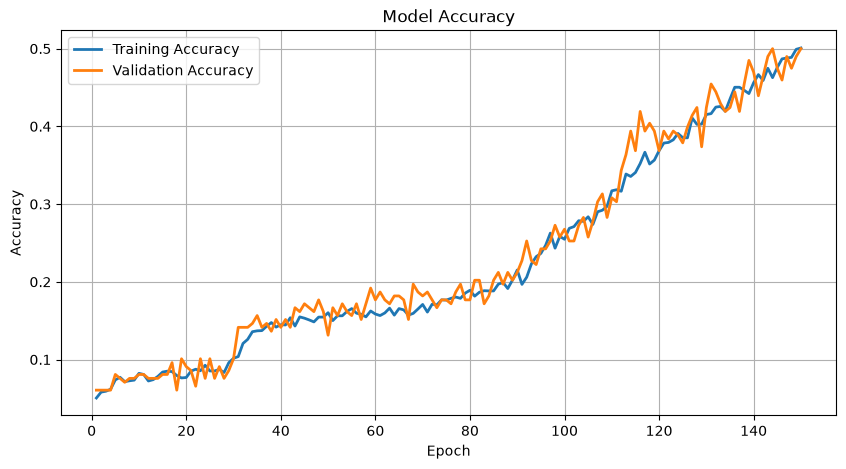

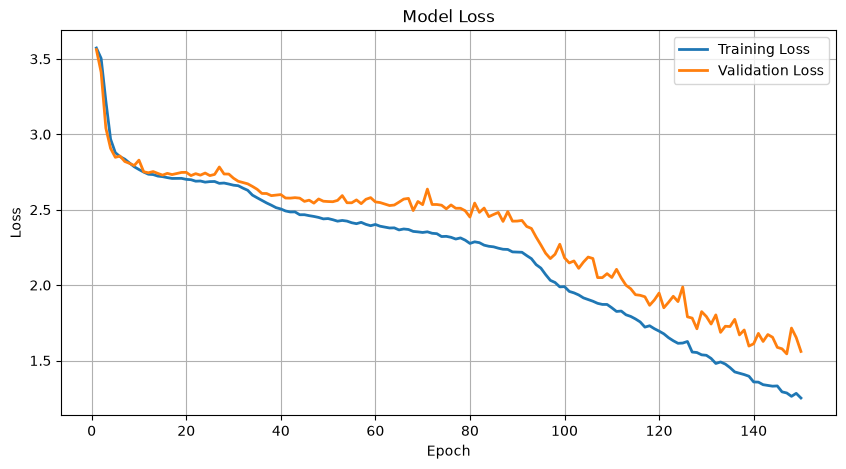

Final Training Accuracy:  0.5008
Final Validation Accuracy: 0.5000
Final Training Loss:       1.2515
Final Validation Loss:     1.5601


In [ ]:
acc = history["train_accuracy"]
val_acc = history["dev_accuracy"]
loss = history["train_loss"]
val_loss = history["dev_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, label="Training Accuracy", linewidth=2)
plt.plot(epochs, val_acc, label="Validation Accuracy", linewidth=2)
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, label="Training Loss", linewidth=2)
plt.plot(epochs, val_loss, label="Validation Loss", linewidth=2)
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Training Accuracy:  {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Final Training Loss:       {loss[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss[-1]:.4f}")

## 5.3. Analisis dan Evaluasi Base Model

================ Evaluasi Base Model ================
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         3
         Apa       0.86      1.00      0.92        12
           B       0.00      0.00      0.00         3
           C       0.00      0.00      0.00         3
           D       0.00      0.00      0.00         3
      Dimana       0.50      0.92      0.65        12
           E       0.25      0.67      0.36         3
           F       0.00      0.00      0.00         3
           G       0.33      0.33      0.33         3
           H       0.00      0.00      0.00         3
       Hallo       0.80      1.00      0.89        12
           I       0.30      1.00      0.46         3
           J       0.00      0.00      0.00         3
           K       0.00      0.00      0.00         3
        Kamu       1.00      0.08      0.15        12
        Kita       0.60      0.50      0.55        12
           L       0.50    

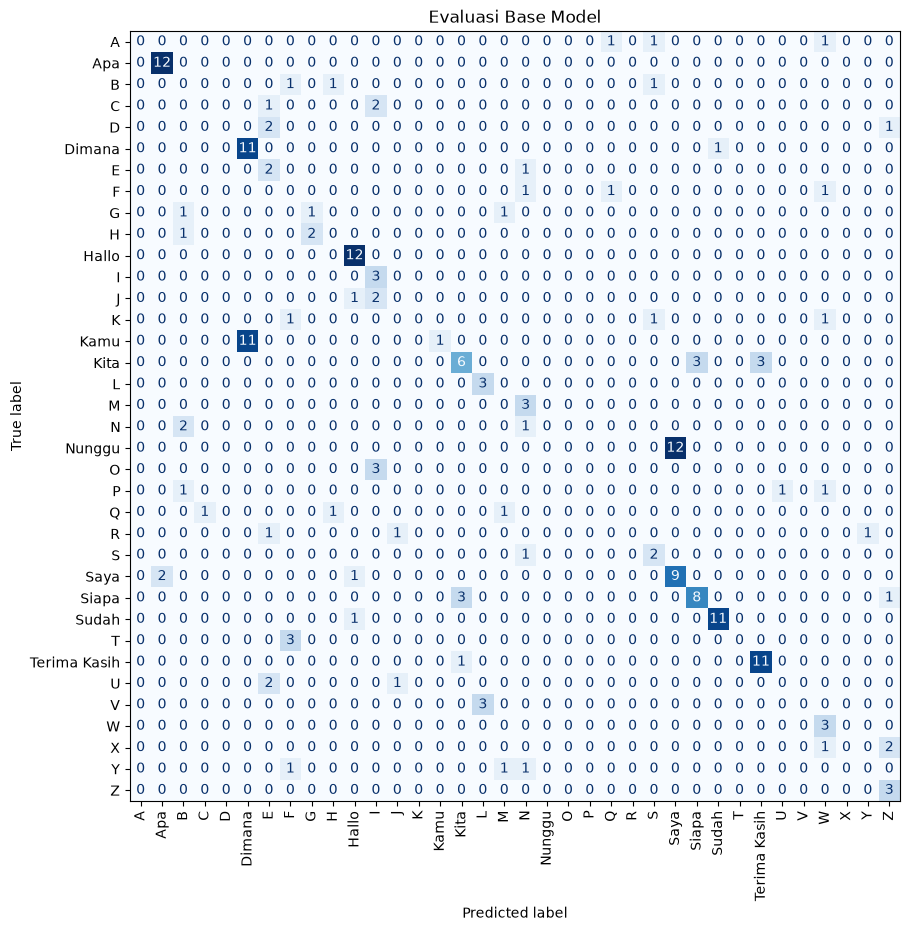

In [ ]:
def predict(model, loader):
    model.eval()
    predictions, targets = [], []
    with torch.no_grad():
        for features, batch_targets in loader:
            logits = model(features.to(device))
            predictions.extend(logits.argmax(dim=1).cpu().numpy())
            targets.extend(batch_targets.numpy())
    return np.asarray(targets), np.asarray(predictions)


def evaluate_model(model, loader, title):
    y_true, y_pred = predict(model, loader)
    print(f"================ {title} ================")
    print(classification_report(
        y_true, y_pred, labels=np.arange(len(actions)), target_names=actions, zero_division=0
    ))
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(actions)))
    fig, ax = plt.subplots(figsize=(12, 10))
    ConfusionMatrixDisplay(cm, display_labels=actions).plot(
        cmap=plt.cm.Blues, ax=ax, xticks_rotation="vertical", colorbar=False
    )
    ax.set_title(title)
    plt.show()
    return y_true, y_pred


y_true_base, y_pred_base = evaluate_model(base_model, test_loader, "Evaluasi Base Model")

In [ ]:
criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = run_epoch(base_model, test_loader, criterion)
print("Mengevaluasi model pada Test Set...")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

Mengevaluasi model pada Test Set...
Test Loss     : 1.4648
Test Accuracy : 0.5000 (50.00%)


## 5.4. Simpan Base Model

In [ ]:
MODEL_DIR = Path("base_model")
MODEL_DIR.mkdir(exist_ok=True)
base_checkpoint = MODEL_DIR / "model_cnn_lstm_isyarat.pt"

torch.save(
    {
        "model_state_dict": base_model.state_dict(),
        "model_config": {
            "filters_1": 64,
            "filters_2": 64,
            "lstm_1": 64,
            "lstm_2": 64,
            "lstm_3": 64,
            "dense_1": 64,
            "dense_2": 32,
            "dropout": 0.2
        },
        "actions": actions.tolist(),
        "video_frames": VIDEO_FRAMES,
        "features": FEATURES,
    },
    base_checkpoint,
)
print(f"Base model disimpan di {base_checkpoint}")

Base model disimpan di base_model/model_cnn_lstm_isyarat.pt


# 6. Hyperparameter Tuning

## 6.1. Setup Tuner

In [ ]:
def sample_hyperparameters():
    return {
        "filters_1": random.choice([32, 64, 96, 128]),
        "filters_2": random.choice([32, 64, 96, 128]),
        "lstm_1": random.choice([32, 64, 96, 128]),
        "lstm_2": random.choice([32, 64, 96, 128]),
        "lstm_3": random.choice([64, 128, 192, 256]),
        "dense_1": random.choice([32, 64, 96, 128]),
        "dense_2": random.choice([32, 64, 96, 128]),
        "dropout": random.choice([0.1, 0.2, 0.3]),
    }


MAX_TRIALS = 100
TUNING_EPOCHS = 100
trial_results = []

## 6.2. Melakukan Hyperparameter Tuning

In [ ]:
def format_elapsed(seconds):
    seconds = int(seconds)
    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{hours:02d}h {minutes:02d}m {seconds:02d}s"


MAX_TRIALS = 100
TUNING_EPOCHS = 100
trial_results = []

tuning_start = time.perf_counter()
best_val_accuracy = 0.0

for trial_index in range(1, MAX_TRIALS + 1):
    trial_start = time.perf_counter()

    config = sample_hyperparameters()
    trial_model = CNNLSTM(
        num_classes=len(actions),
        **config,
    ).to(device)
    trial_history = fit_model(
        trial_model,
        train_loader,
        dev_loader,
        epochs=TUNING_EPOCHS,
        patience=PATIENCE,
        learning_rate=1e-4,
    )

    trial_val_accuracy = max(trial_history["dev_accuracy"])
    trial_results.append({
        "config": config,
        "dev_accuracy": trial_val_accuracy,
    })

    best_val_accuracy = max(best_val_accuracy, trial_val_accuracy)
    trial_elapsed = time.perf_counter() - trial_start
    total_elapsed = time.perf_counter() - tuning_start
    average_trial_time = total_elapsed / trial_index
    remaining_time = average_trial_time * (MAX_TRIALS - trial_index)

    print(f"\nTrial {trial_index} Complete [{format_elapsed(trial_elapsed)}]")
    print(f"val_categorical_accuracy: {trial_val_accuracy:.6f}")
    print()
    print(f"Best val_categorical_accuracy So Far: {best_val_accuracy:.6f}")
    print(f"Total elapsed time: {format_elapsed(total_elapsed)}")
    print(f"Estimated remaining time: {format_elapsed(remaining_time)}")

Epoch 001/100 | train loss 3.5779, acc 0.0152 | dev loss 3.5675, acc 0.0152
Epoch 002/100 | train loss 3.5024, acc 0.0522 | dev loss 3.3823, acc 0.0606
Epoch 003/100 | train loss 3.2125, acc 0.0637 | dev loss 3.0858, acc 0.0657
Epoch 004/100 | train loss 3.0117, acc 0.0940 | dev loss 2.9632, acc 0.0808
Epoch 005/100 | train loss 2.9084, acc 0.1198 | dev loss 2.8627, acc 0.1162
Epoch 006/100 | train loss 2.8476, acc 0.1178 | dev loss 2.8177, acc 0.1212
Epoch 007/100 | train loss 2.7798, acc 0.1156 | dev loss 2.7584, acc 0.1162
Epoch 008/100 | train loss 2.7216, acc 0.1192 | dev loss 2.6796, acc 0.1162
Epoch 009/100 | train loss 2.6827, acc 0.1319 | dev loss 2.6549, acc 0.1162
Epoch 010/100 | train loss 2.6631, acc 0.1226 | dev loss 2.6540, acc 0.1162
Epoch 011/100 | train loss 2.6424, acc 0.1181 | dev loss 2.6443, acc 0.1212
Epoch 012/100 | train loss 2.6273, acc 0.1187 | dev loss 2.6119, acc 0.1212
Epoch 013/100 | train loss 2.6077, acc 0.1293 | dev loss 2.6110, acc 0.1364
Epoch 014/10

In [ ]:
best_trial = max(trial_results, key=lambda result: result["dev_accuracy"])
best_config = best_trial["config"]
print("=== Pencarian Selesai! ===")
print("Kombinasi Hyperparameter Terbaik Ditemukan:")
print(best_config)
print(f"Best Dev Accuracy: {best_trial['dev_accuracy']:.4f}")

=== Pencarian Selesai! ===
Kombinasi Hyperparameter Terbaik Ditemukan:
{'filters_1': 128, 'filters_2': 96, 'lstm_1': 96, 'lstm_2': 64, 'lstm_3': 128, 'dense_1': 96, 'dense_2': 32, 'dropout': 0.1}
Best Dev Accuracy: 0.7727


In [ ]:
print("Me-retrain model terbaik...")
tuned_model = CNNLSTM(num_classes=len(actions), **best_config).to(device)
tuned_history = fit_model(tuned_model, train_loader, dev_loader)

Me-retrain model terbaik...
Epoch 001/150 | train loss 3.5777, acc 0.0157 | dev loss 3.5603, acc 0.0152
Epoch 002/150 | train loss 3.4836, acc 0.0553 | dev loss 3.3293, acc 0.0606
Epoch 003/150 | train loss 3.1294, acc 0.0654 | dev loss 2.9716, acc 0.0606
Epoch 004/150 | train loss 2.9080, acc 0.0556 | dev loss 2.8760, acc 0.0657
Epoch 005/150 | train loss 2.8585, acc 0.0668 | dev loss 2.8560, acc 0.0758
Epoch 006/150 | train loss 2.8348, acc 0.0741 | dev loss 2.8210, acc 0.0808
Epoch 007/150 | train loss 2.8091, acc 0.0732 | dev loss 2.8113, acc 0.0859
Epoch 008/150 | train loss 2.7757, acc 0.0735 | dev loss 2.7697, acc 0.0758
Epoch 009/150 | train loss 2.7483, acc 0.0802 | dev loss 2.7772, acc 0.0859
Epoch 010/150 | train loss 2.7257, acc 0.0755 | dev loss 2.7544, acc 0.0909
Epoch 011/150 | train loss 2.7135, acc 0.0730 | dev loss 2.7420, acc 0.1010
Epoch 012/150 | train loss 2.7000, acc 0.0842 | dev loss 2.7681, acc 0.0808
Epoch 013/150 | train loss 2.6881, acc 0.0842 | dev loss 2.7

## 6.3. Analisis Model Terbaik Setelah Tuning

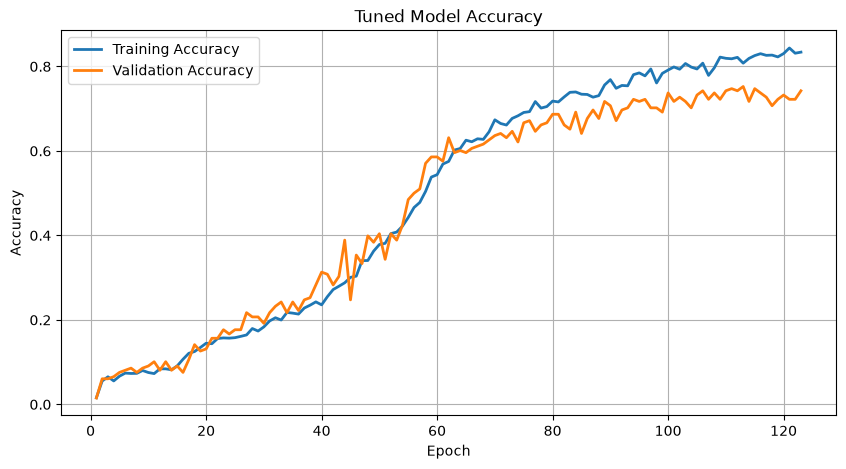

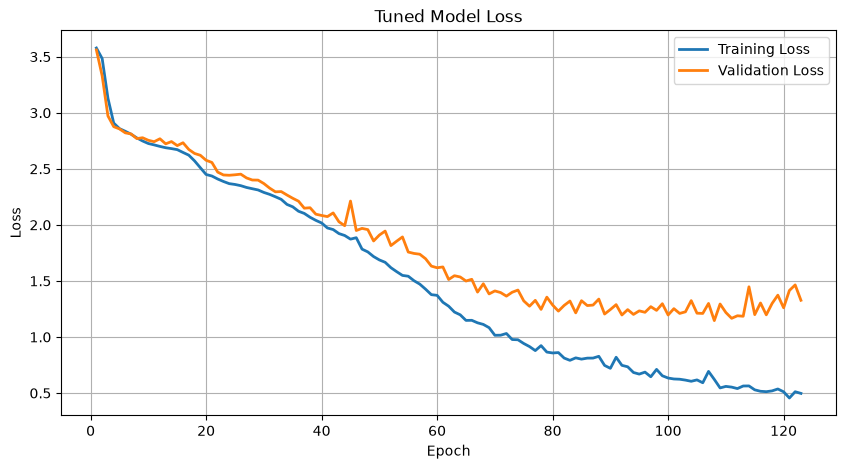

Final Training Accuracy:  0.8339
Final Validation Accuracy: 0.7424
Final Training Loss:       0.4970
Final Validation Loss:     1.3276


In [ ]:
acc_tuned = tuned_history["train_accuracy"]
val_acc_tuned = tuned_history["dev_accuracy"]
loss_tuned = tuned_history["train_loss"]
val_loss_tuned = tuned_history["dev_loss"]
epochs_tuned = range(1, len(acc_tuned) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_tuned, acc_tuned, label="Training Accuracy", linewidth=2)
plt.plot(epochs_tuned, val_acc_tuned, label="Validation Accuracy", linewidth=2)
plt.title("Tuned Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_tuned, loss_tuned, label="Training Loss", linewidth=2)
plt.plot(epochs_tuned, val_loss_tuned, label="Validation Loss", linewidth=2)
plt.title("Tuned Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Training Accuracy:  {acc_tuned[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc_tuned[-1]:.4f}")
print(f"Final Training Loss:       {loss_tuned[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss_tuned[-1]:.4f}")

================ Confusion Matrix Model Setelah Hyperparameter Tuning ================
              precision    recall  f1-score   support

           A       0.33      0.33      0.33         3
         Apa       0.86      1.00      0.92        12
           B       0.33      0.33      0.33         3
           C       0.50      1.00      0.67         3
           D       0.50      0.33      0.40         3
      Dimana       1.00      0.92      0.96        12
           E       0.60      1.00      0.75         3
           F       0.00      0.00      0.00         3
           G       0.67      0.67      0.67         3
           H       0.33      0.33      0.33         3
       Hallo       0.92      0.92      0.92        12
           I       1.00      1.00      1.00         3
           J       0.00      0.00      0.00         3
           K       1.00      0.33      0.50         3
        Kamu       0.86      1.00      0.92        12
        Kita       1.00      0.92      0.96     

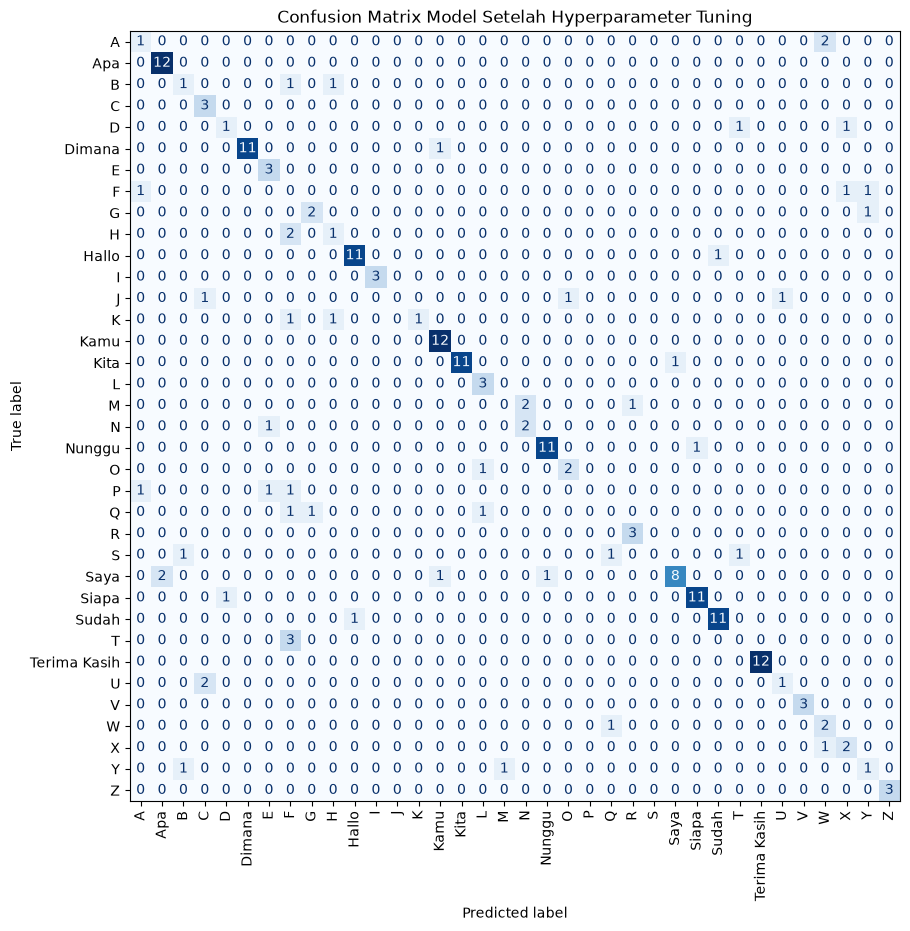

Mengevaluasi model tuned pada Test Set...
Test Loss     : 1.1833
Test Accuracy : 0.7475 (74.75%)


In [ ]:
y_true_tuned, y_pred_tuned = evaluate_model(
    tuned_model,
    test_loader,
    "Confusion Matrix Model Setelah Hyperparameter Tuning",
)
criterion = nn.CrossEntropyLoss()
tuned_test_loss, tuned_test_accuracy = run_epoch(tuned_model, test_loader, criterion)
print("Mengevaluasi model tuned pada Test Set...")
print(f"Test Loss     : {tuned_test_loss:.4f}")
print(f"Test Accuracy : {tuned_test_accuracy:.4f} ({tuned_test_accuracy * 100:.2f}%)")

## 6.4. Simpan Model Terbaik

In [ ]:
BEST_MODEL_DIR = Path("best_model")
BEST_MODEL_DIR.mkdir(exist_ok=True)
best_checkpoint = BEST_MODEL_DIR / "model_cnn_lstm_isyarat.pt"
torch.save(
    {
        "model_state_dict": tuned_model.state_dict(),
        "model_config": best_config,
        "actions": actions.tolist(),
        "video_frames": VIDEO_FRAMES,
        "features": FEATURES,
    },
    best_checkpoint,
)
print(f"Best model disimpan di {best_checkpoint}")

Best model disimpan di best_model/model_cnn_lstm_isyarat.pt
